In [ ]:
# =============================================================================
# 🚀 ONGLETS GÉNÉRER - TEST COMPLET (EasyOCR + NER + BART)
# =============================================================================

import torch
from transformers import pipeline
from PIL import Image
import easyocr
import gradio as gr
from io import BytesIO
import requests

print("✅ Imports OK - Chargement modèles... (patience 3-4min)")

# ===============================================
# 1. CHARGEMENT MODÈLES (AUTOMATIQUE)
# ===============================================
print("🔄 1/3 EasyOCR (OCR)...")
reader = easyocr.Reader(['fr', 'en'])  # Français + Anglais

print("🔄 2/3 NER BERT...")
ner_pipeline = pipeline(
    "ner", 
    model="dbmdz/bert-large-cased-finetuned-conll03-english",
    aggregation_strategy="simple"
)

print("🔄 3/3 BART Summarization...")
summarizer = pipeline(
    "summarization", 
    model="sshleifer/distilbart-cnn-12-6",  # Plus léger que BART-large !
    device=0 if torch.cuda.is_available() else -1
)

print("✅ TOUS MODÈLES CHARGÉS !")

# ===============================================
# 2. FONCTIONS CHAINAGE
# ===============================================
def ocr_easyocr(image):
    """EasyOCR → Texte brut"""
    if image is None:
        return "❌ Chargez une image"
    
    # EasyOCR sur image PIL
    result = reader.readtext(image)
    texte = " ".join([detection[1] for detection in result])
    return texte if texte else "❌ Aucun texte détecté"

def ner_entites(texte):
    """BERT NER → Entités nommées"""
    if not texte or len(texte) < 10:
        return []
    
    entites = ner_pipeline(texte)
    return [
        {"entity": e["entity_group"], "word": e["word"], "score": round(e["score"], 3)}
        for e in entites if e["score"] > 0.7  # Seuil confiance
    ][:6]  # Top 6

def bart_resume(texte):
    """DistilBART → Résumé intelligent"""
    if not texte or len(texte) < 20:
        return "❌ Texte trop court pour résumé"
    
    # Tronque à 1000 chars (limite modèle)
    texte_court = texte[:1000]
    resume = summarizer(
        texte_court,
        max_length=120,
        min_length=30,
        do_sample=False,
        truncation=True
    )[0]['summary_text']
    return resume

def pipeline_complet(image):
    """FLUX COMPLET : OCR → NER → RÉSUMÉ"""
    if image is None:
        return "❌ Pas d'image", "❌ Pas d'image", [], "❌ Chargez une image"
    
    # 1. OCR
    print("🔍 OCR en cours...")
    texte = ocr_easyocr(image)
    
    # 2. NER
    print("🔑 Extraction entités...")
    entites = ner_entites(texte)
    
    # 3. Résumé
    print("✨ Génération résumé...")
    resume = bart_resume(texte)
    
    return texte, entites, resume

# ===============================================
# 3. FONCTION FORMATAGE AFFICHAGE
# ===============================================
def format_entites(entites):
    """Beau affichage entités"""
    if not entites:
        return "❌ Aucune entité détectée"
    
    lignes = []
    for e in entites:
        lignes.append(f"• **{e['entity']}**: {e['word']} ({e['score']:.0%})")
    return "\n".join(lignes)

# ===============================================
# 4. TEST AUTOMATIQUE (Image facture exemple)
# ===============================================
print("\n🚀 === TEST AUTOMATIQUE ===")
# Image test (facture publique)
url_test = "https://www.invoice-home.com/wp-content/uploads/2019/11/sample-invoice-1.png"
response = requests.get(url_test)
image_test = Image.open(BytesIO(response.content))

print("🧪 Test pipeline complet...")
texte_test, entites_test, resume_test = pipeline_complet(image_test)

print("\n📄 1. TEXTE OCR:")
print("-" * 50)
print(texte_test[:200] + "..." if len(texte_test) > 200 else texte_test)

print("\n🔑 2. ENTITÉS NER:")
print("-" * 50)
print(format_entites(entites_test))

print("\n✨ 3. RÉSUMÉ BART:")
print("-" * 50)
print(resume_test)

# ===============================================
# 5. INTERFACE GRADIO (votre onglet "Générer")
# ===============================================
with gr.Blocks(title="📄 Summarize AI - Onglet Générer") as demo:
    gr.Markdown("# 📄 **Onglet GÉNÉRER** - Test Complet")
    gr.Markdown("**EasyOCR → NER BERT → DistilBART** (4GB auto-téléchargés)")
    
    with gr.Row():
        with gr.Column(scale=1):
            img_input = gr.Image(
                label="📷 Chargez JPEG/PNG", 
                type="pil",
                height=300
            )
            btn_analyse = gr.Button("🔬 ANALYSER COMPLET", variant="primary")
        
        with gr.Column(scale=2):
            gr.Markdown("### 📊 **Résultats**")
            
            texte_out = gr.Textbox(label="1️⃣ Texte OCR", lines=6)
            entites_out = gr.Textbox(label="2️⃣ Entités NER", lines=4)
            resume_out = gr.Textbox(label="3️⃣ Résumé IA", lines=4)
    
    # ÉVÉNEMENTS
    btn_analyse.click(
        pipeline_complet,
        inputs=img_input,
        outputs=[texte_out, entites_out, resume_out]
    )
    
    # Exemple pré-chargé
    gr.Examples(
        examples=[[url_test]],
        inputs=[img_input],
        label="🧪 Test rapide"
    )

print("\n🎉 Notebook prêt ! Lancez demo.launch() ou copiez dans app.py")
demo.launch(share=False, debug=True)


In [ ]:
# =============================================================================
# 🚀 ONGLETS GÉNÉRER - VERSION DEBUG (Warnings OFF + Progression)
# =============================================================================

# 1. SUPPRESSION WARNINGS (CRITIQUE)
import os
os.environ['HF_HUB_DISABLE_SYMLINKS_WARNING'] = '1'
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

import torch
import warnings
warnings.filterwarnings("ignore")

from transformers import pipeline
from PIL import Image
import easyocr
import gradio as gr
from io import BytesIO
import requests
import time

print("✅ 1/6 Imports OK")

# ===============================================
# 2. CHARGEMENT MODÈLES (AVEC TIMING)
# ===============================================
print("\n🔄 2/6 EasyOCR (30s)...")
start = time.time()
reader = easyocr.Reader(['fr', 'en'], download_enabled=True)
print(f"✅ EasyOCR: {time.time()-start:.0f}s")

print("\n🔄 3/6 NER BERT (1min)...")
start = time.time()
ner_pipeline = pipeline(
    "ner", 
    model="dbmdz/bert-large-cased-finetuned-conll03-english",
    aggregation_strategy="simple"
)
print(f"✅ NER BERT: {time.time()-start:.0f}s")

print("\n🔄 4/6 DistilBART (1min)...")
start = time.time()
summarizer = pipeline(
    "summarization", 
    model="sshleifer/distilbart-cnn-12-6"
)
print(f"✅ DistilBART: {time.time()-start:.0f}s")

print("\n✅ 5/6 TOUS MODÈLES CHARGÉS ! (Total:", time.time()-start, "s)")

# ===============================================
# FONCTIONS (identiques mais optimisées)
# ===============================================
def pipeline_complet(image):
    if image is None:
        return "❌ Pas d'image", "❌ Pas d'image", [], "❌ Chargez une image"
    
    print("🔍 1/3 OCR...")
    result = reader.readtext(image)
    texte = " ".join([detection[1] for detection in result])
    
    print("🔑 2/3 NER...")
    entites = ner_pipeline(texte) if texte else []
    entites_fmt = [{"entity": e["entity_group"], "word": e["word"], "score": e["score"]} 
                   for e in entites if e["score"] > 0.7][:6]
    
    print("✨ 3/3 Résumé...")
    resume = summarizer(texte[:1000], max_length=80, min_length=20, do_sample=False)[0]['summary_text'] if texte else "❌ Pas de texte"
    
    return texte, entites_fmt, resume

def format_entites(entites):
    if not entites: return "❌ Aucune entité"
    return "\n".join([f"• {e['entity']}: **{e['word']}** ({e['score']:.0%})" for e in entites])

# ===============================================
# 6/6 INTERFACE GRADIO
# ===============================================
url_test = "https://www.invoice-home.com/wp-content/uploads/2019/11/sample-invoice-1.png"

with gr.Blocks(title="📄 Summarize AI") as demo:
    gr.Markdown("# 📄 **Onglet GÉNÉRER** - ✅ Prêt !")
    
    with gr.Row():
        with gr.Column(scale=1):
            img_input = gr.Image(label="📷 Image", type="pil")
            btn_test = gr.Button("🧪 TEST RAPIDE", variant="primary")
        
        with gr.Column(scale=2):
            texte_out = gr.Textbox(label="📄 Texte OCR", lines=6)
            entites_out = gr.Textbox(label="🔑 Entités", lines=4)
            resume_out = gr.Textbox(label="✨ Résumé", lines=4)
    
    btn_test.click(pipeline_complet, img_input, [texte_out, entites_out, resume_out])
    
    gr.Examples([[url_test]], img_input)

print("\n🎉 6/6 INTERFACE PRÊTE !")
demo.launch(share=False, debug=True, show_error=True)


In [ ]:
# =============================================================================
# 🚀 ONGLETS GÉNÉRER - VERSION FINALE (✅ Sans erreur Examples)
# =============================================================================

# SUPPRESSION WARNINGS
import os
os.environ['HF_HUB_DISABLE_SYMLINKS_WARNING'] = '1'
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

import torch
import warnings
warnings.filterwarnings("ignore")

from transformers import pipeline
from PIL import Image
import easyocr
import gradio as gr
from io import BytesIO
import requests
import time

print("✅ 1/6 Imports OK")

# ===============================================
# CHARGEMENT MODÈLES (TIMING)
# ===============================================
print("\n🔄 2/6 EasyOCR...")
start = time.time()
reader = easyocr.Reader(['fr', 'en'])
print(f"✅ EasyOCR: {time.time()-start:.0f}s")

print("\n🔄 3/6 NER BERT...")
start = time.time()
ner_pipeline = pipeline("ner", 
                       model="dbmdz/bert-large-cased-finetuned-conll03-english", 
                       aggregation_strategy="simple")
print(f"✅ NER: {time.time()-start:.0f}s")

print("\n🔄 4/6 DistilBART...")
start = time.time()
summarizer = pipeline("summarization", 
                     model="sshleifer/distilbart-cnn-12-6")
print(f"✅ BART: {time.time()-start:.0f}s")

print("\n✅ 5/6 TOUS MODÈLES CHARGÉS !")

# ===============================================
# FONCTIONS OPTIMISÉES
# ===============================================
def pipeline_complet(image):
    if image is None:
        return "", "❌ Chargez une image", "❌ Chargez une image", []
    
    # 1. OCR
    result = reader.readtext(image)
    texte = " ".join([detection[1] for detection in result])
    
    # 2. NER
    entites = []
    if texte and len(texte) > 10:
        entites_raw = ner_pipeline(texte)
        entites = [{"entity": e["entity_group"], "word": e["word"], "score": e["score"]} 
                   for e in entites_raw if e["score"] > 0.7][:6]
    
    # 3. Résumé
    resume = "❌ Texte insuffisant"
    if texte and len(texte) > 20:
        resume = summarizer(texte[:1000], max_length=80, min_length=20, do_sample=False)[0]['summary_text']
    
    return texte, format_entites(entites), resume

def format_entites(entites):
    if not entites:
        return "❌ Aucune entité détectée"
    return "\n".join([f"• **{e['entity']}**: {e['word']} ({e['score']:.0%})" for e in entites])

# ===============================================
# INTERFACE GRADIO (✅ SANS Examples buggé)
# ===============================================
with gr.Blocks(title="📄 Summarize AI") as demo:
    gr.Markdown("# 📄 **Onglet GÉNÉRER** - ✅ PRÊT !")
    gr.Markdown("**EasyOCR → NER BERT → DistilBART**")
    
    with gr.Row():
        with gr.Column(scale=1):
            img_input = gr.Image(label="📷 Chargez JPEG/PNG", type="pil", height=300)
            btn_analyse = gr.Button("🔬 ANALYSER", variant="primary")
        
        with gr.Column(scale=2):
            gr.Markdown("### 📊 Résultats")
            texte_out = gr.Textbox(label="1️⃣ Texte OCR", lines=6)
            entites_out = gr.Textbox(label="2️⃣ Entités NER", lines=4)
            resume_out = gr.Textbox(label="3️⃣ Résumé IA", lines=4)
    
    btn_analyse.click(
        pipeline_complet,
        inputs=img_input,
        outputs=[texte_out, entites_out, resume_out]
    )
    
    gr.Markdown("**💡 Testez avec n'importe quelle facture/photo texte !**")

print("\n🎉 INTERFACE PARFAITE !")
demo.launch(share=False, debug=True)


In [ ]:
# =============================================================================
# 🚀 VERSION FINALE - EASYOCR FIXÉ
# =============================================================================

import os
os.environ['HF_HUB_DISABLE_SYMLINKS_WARNING'] = '1'
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

import torch
import numpy as np  # 🔥 FIX EASYOCR
import warnings
warnings.filterwarnings("ignore")

from transformers import pipeline
from PIL import Image
import easyocr
import gradio as gr
import time

print("✅ Imports OK")

# CHARGEMENT MODÈLES (gardez vos modèles déjà chargés)
reader = easyocr.Reader(['fr', 'en'])
ner_pipeline = pipeline("ner", model="dbmdz/bert-large-cased-finetuned-conll03-english", aggregation_strategy="simple")
summarizer = pipeline("summarization", model="sshleifer/distilbart-cnn-12-6")

def format_entites(entites):
    if not entites: return "❌ Aucune entité"
    return "\n".join([f"• **{e['entity']}**: {e['word']} ({e['score']:.0%})" for e in entites])

def pipeline_complet(image):
    if image is None:
        return "", "❌ Chargez une image", "❌ Chargez une image"
    
    # 🔥 CONVERSION PIL → NUMPY (FIX EASYOCR)
    image_np = np.array(image)
    
    # 1. OCR
    result = reader.readtext(image_np)
    texte = " ".join([detection[1] for detection in result]).strip()
    
    # 2. NER
    entites = []
    if texte and len(texte) > 10:
        entites_raw = ner_pipeline(texte)
        entites = [{"entity": e["entity_group"], "word": e["word"], "score": e["score"]} 
                   for e in entites_raw if e["score"] > 0.7][:6]
    
    # 3. Résumé
    resume = "❌ Texte insuffisant"
    if texte and len(texte) > 20:
        resume = summarizer(texte[:1000], max_length=80, min_length=20, do_sample=False)[0]['summary_text']
    
    return texte, format_entites(entites), resume

# INTERFACE
with gr.Blocks(title="📄 Summarize AI - ✅ FIXÉ") as demo:
    gr.Markdown("# 📄 **Onglet GÉNÉRER** - EasyOCR ✅")
    
    with gr.Row():
        with gr.Column(scale=1):
            img_input = gr.Image(label="📷 Facture/PNG/JPG", type="pil")
            btn_analyse = gr.Button("🔬 ANALYSER", variant="primary")
        
        with gr.Column(scale=2):
            texte_out = gr.Textbox(label="📄 Texte OCR", lines=6)
            entites_out = gr.Textbox(label="🔑 Entités", lines=4)
            resume_out = gr.Textbox(label="✨ Résumé", lines=4)
    
    btn_analyse.click(pipeline_complet, img_input, [texte_out, entites_out, resume_out])

demo.launch(share=False, debug=True)


In [ ]:
# app.py - FastAPI + Gradio intégré
from fastapi import FastAPI, UploadFile, File, HTTPException
from fastapi.middleware.cors import CORSMiddleware
import gradio as gr
from main import ai_engine
from PIL import Image
import io

app = FastAPI(title="📄 Summarize AI API")

# CORS pour frontend
app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_credentials=True,
    allow_methods=["*"],
    allow_headers=["*"],
)

# ===============================================
# ROUTES API
# ===============================================
@app.post("/api/analyse")
async def api_analyse(file: UploadFile = File(...)):
    """API endpoint pour analyse"""
    if not file.content_type.startswith('image/'):
        raise HTTPException(400, "Fichier image requis")
    
    content = await file.read()
    result = ai_engine.pipeline_complet(io.BytesIO(content))
    
    if result["status"] == "error":
        raise HTTPException(500, result["message"])
    
    return result

@app.get("/health")
async def health():
    return {"status": "OK", "service": "Summarize AI"}

# ===============================================
# GRADIO FRONTEND INTÉGRÉ
# ===============================================
def gradio_analyse(image):
    """Fonction Gradio → API"""
    if image is None:
        return "", "❌ Chargez une image", "❌ Chargez une image"
    
    # Image → Bytes → API → Résultat
    img_bytes = io.BytesIO()
    image.save(img_bytes, format='PNG')
    img_bytes = img_bytes.getvalue()
    
    result = ai_engine.pipeline_complet(io.BytesIO(img_bytes))
    
    if result["status"] == "error":
        return "", "❌ Erreur", result["message"]
    
    entites_fmt = "\n".join([
        f"• **{e['entity']}**: {e['word']} ({e['score']:.0%})"
        for e in result["entites"]
    ]) if result["entites"] else "❌ Aucune entité"
    
    return result["texte"], entites_fmt, result["resume"]

# Interface Gradio
with gr.Blocks(title="📄 Summarize AI", theme=gr.themes.Soft()) as demo:
    gr.Markdown("# 📄 **Summarize AI** - OCR + NER + Résumé")
    gr.Markdown("**EasyOCR → BERT NER → DistilBART**")
    
    with gr.Row():
        with gr.Column(scale=1):
            img_input = gr.Image(
                label="📷 Facture / Document", 
                type="pil",
                height=300
            )
            btn_analyse = gr.Button("🔬 ANALYSER", variant="primary", size="lg")
        
        with gr.Column(scale=2):
            gr.Markdown("### 📊 Résultats")
            texte_out = gr.Textbox(label="1️⃣ Texte OCR", lines=6)
            entites_out = gr.Textbox(label="2️⃣ Entités NER", lines=4)
            resume_out = gr.Textbox(label="3️⃣ Résumé IA", lines=4)
    
    # Événements
    btn_analyse.click(
        gradio_analyse,
        inputs=img_input,
        outputs=[texte_out, entites_out, resume_out]
    )
    
    gr.Markdown("**💾 API: POST /api/analyse**")

# Monte Gradio sur FastAPI
app = gr.mount_gradio_app(app, demo, path="/")

if __name__ == "__main__":
    import uvicorn
    uvicorn.run(app, host="127.0.0.1", port=8000, reload=True)


In [ ]:
# main.py - Logique OCR/NER/Résumé
import os
import numpy as np
from PIL import Image
import easyocr
from transformers import pipeline
import warnings
warnings.filterwarnings("ignore")

# Suppression warnings
os.environ['HF_HUB_DISABLE_SYMLINKS_WARNING'] = '1'
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

class SummarizeAI:
    def __init__(self):
        print("🔄 Chargement modèles...")
        self.reader = easyocr.Reader(['fr', 'en'])
        self.ner_pipeline = pipeline(
            "ner", 
            model="dbmdz/bert-large-cased-finetuned-conll03-english", 
            aggregation_strategy="simple"
        )
        self.summarizer = pipeline(
            "summarization", 
            model="sshleifer/distilbart-cnn-12-6"
        )
        print("✅ Modèles chargés !")

    def pipeline_complet(self, image_bytes):
        """FLUX COMPLET : OCR → NER → RÉSUMÉ"""
        try:
            # Image bytes → PIL → NumPy
            image = Image.open(image_bytes).convert('RGB')
            image_np = np.array(image)
            
            # 1. OCR
            result = self.reader.readtext(image_np)
            texte = " ".join([detection[1] for detection in result]).strip()
            
            # 2. NER
            entites = []
            if texte and len(texte) > 10:
                entites_raw = self.ner_pipeline(texte)
                entites = [
                    {"entity": e["entity_group"], "word": e["word"], "score": round(e["score"], 3)}
                    for e in entites_raw if e["score"] > 0.7
                ][:6]
            
            # 3. Résumé
            resume = "❌ Texte insuffisant"
            if texte and len(texte) > 20:
                resume = self.summarizer(
                    texte[:1000], 
                    max_length=80, 
                    min_length=20, 
                    do_sample=False
                )[0]['summary_text']
            
            return {
                "texte": texte or "❌ Aucun texte détecté",
                "entites": entites,
                "resume": resume,
                "status": "success"
            }
        except Exception as e:
            return {"status": "error", "message": str(e)}

# Instance globale
ai_engine = SummarizeAI()


In [ ]:
# Import des bibliothèques nécessaires
from transformers import pipeline
import torch

# Chargement du modèle BART-large-cnn spécialisé en summarisation
print("Chargement du modèle facebook/bart-large-cnn...")
summarizer = pipeline(
    "summarization",
    model="facebook/bart-large-cnn",
    device=0 if torch.cuda.is_available() else -1,  # GPU si disponible
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32
)
print("Modèle chargé !")

# Exemple de texte long à résumer (article fictif)
texte_long = """
L'intelligence artificielle transforme radicalement le monde du développement logiciel. Les modèles de langage comme GPT-4 et Llama permettent désormais de générer du code Python, JavaScript et même des architectures complètes de bases de données. Les développeurs utilisent ces outils pour accélérer le prototyping, déboguer plus rapidement et explorer de nouvelles idées d'algorithmes.

En data science, les frameworks comme Hugging Face Transformers simplifient l'accès aux modèles pré-entraînés pour la classification de texte, la reconnaissance d'entités nommées (NER) et la summarisation automatique. Les bootcamps comme Simplon forment les étudiants à intégrer ces technologies dans des applications full-stack avec FastAPI en backend et Streamlit en frontend.

Cependant, des défis persistent : les modèles peuvent halluciner des informations incorrectes, nécessitant une validation humaine. La consommation GPU reste élevée pour les gros modèles, et les licences d'usage varient selon les fournisseurs. Malgré cela, l'IA devient indispensable pour rester compétitif en 2025.
"""

# Paramètres de summarisation optimisés
max_length = 150    # Longueur max du résumé (mots)
min_length = 40     # Longueur min du résumé
do_sample = False   # Déterministe (pas d'échantillonnage aléatoire)

# Génération du résumé
print("\n=== TEXTE ORIGINAL ({} caractères) ===".format(len(texte_long)))
print(texte_long[:500] + "..." if len(texte_long) > 500 else texte_long)

print("\n=== RÉSUMÉ GÉNÉRÉ ===")
resume = summarizer(
    texte_long,
    max_length=max_length,
    min_length=min_length,
    do_sample=do_sample,
    truncation=True
)
print(resume[0]['summary_text'])

# Fonction réutilisable pour summariser n'importe quel texte
def resumer_texte(texte, max_len=150, min_len=40):
    """
    Fonction simple pour résumer du texte avec BART.
    
    Args:
        texte (str): Texte à résumer
        max_len (int): Longueur max du résumé
        min_len (int): Longueur min du résumé
    
    Returns:
        str: Résumé généré
    """
    if len(texte) < 50:
        return "Texte trop court pour summariser."
    
    result = summarizer(texte, max_length=max_len, min_length=min_len, 
                       do_sample=False, truncation=True)
    return result[0]['summary_text']

# Test de la fonction
texte_test = "Python est un langage de programmation polyvalent utilisé en web development, data science et machine learning. Avec des bibliothèques comme Pandas, NumPy et Transformers, il domine le domaine de l'IA."
print(f"\n=== TEST FONCTION ===")
print("Texte:", texte_test)
print("Résumé:", resumer_texte(texte_test))


In [ ]:

# Redémarrage du runtime si nécessaire (Colab seulement)
# import os
# os.kill(os.getpid(), 9)

# Import des bibliothèques
from transformers import pipeline
import torch

# Chargement du modèle avec la syntaxe à jour (dtype au lieu de torch_dtype)
print("Chargement du modèle facebook/bart-large-cnn...")
summarizer = pipeline(
    "summarization",
    model="facebook/bart-large-cnn",
    device=0 if torch.cuda.is_available() else -1,
    dtype=torch.float16 if torch.cuda.is_available() else torch.float32  # Corrigé !
)
print("✅ Modèle chargé avec succès !")

# Votre texte exemple (inchangé)
texte_long = """
L'intelligence artificielle transforme radicalement le monde du développement logiciel. Les modèles de langage comme GPT-4 et Llama permettent désormais de générer du code Python, JavaScript et même des architectures complètes de bases de données. Les développeurs utilisent ces outils pour accélérer le prototyping, déboguer plus rapidement et explorer de nouvelles idées d'algorithmes.

En data science, les frameworks comme Hugging Face Transformers simplifient l'accès aux modèles pré-entraînés pour la classification de texte, la reconnaissance d'entités nommées (NER) et la summarisation automatique. Les bootcamps comme Simplon forment les étudiants à intégrer ces technologies dans des applications full-stack avec FastAPI en backend et Streamlit en frontend.

Cependant, des défis persistent : les modèles peuvent halluciner des informations incorrectes, nécessitant une validation humaine. La consommation GPU reste élevée pour les gros modèles, et les licences d'usage varient selon les fournisseurs. Malgré cela, l'IA devient indispensable pour rester compétitif en 2025.
"""

# Génération du résumé
print("\n=== RÉSUMÉ GÉNÉRÉ ===")
resume = summarizer(
    texte_long,
    max_length=150,
    min_length=40,
    do_sample=False,
    truncation=True
)
print(resume[0]['summary_text'])


In [ ]:
# Téléchargez le modèle en avance (exécutez dans une cellule séparée)
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch

print("📥 Téléchargement manuel facebook/bart-large-cnn...")
model_name = "facebook/bart-large-cnn"

# Téléchargeur avec progression visible
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    low_cpu_mem_usage=True
)

print("✅ Modèle téléchargé et mis en cache local !")
print(f"📁 Cache: {tokenizer.cache_dir or '~/.cache/huggingface/hub'}")


In [ ]:
# ✅ MODÈLE DÉJÀ TÉLÉCHARGÉ - VÉRIFICATION + UTILISATION
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, pipeline
import torch
from pathlib import Path

model_name = "facebook/bart-large-cnn"
print("🔍 Vérification cache local...")

# Cache HuggingFace par défaut
cache_dir = Path.home() / ".cache" / "huggingface" / "hub"
bart_cache = list(cache_dir.glob("models--facebook--bart-large-cnn*"))
print(f"✅ {len(bart_cache)} fichiers BART trouvés dans cache !")

# Chargement RAPIDE du pipeline (0.5s au lieu de 10min)
print("\n⚡ Pipeline prêt en 1 seconde...")
summarizer = pipeline(
    "summarization",
    model=model_name,
    device=0 if torch.cuda.is_available() else -1,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32
)
print("🎉 BART-LARGE-CNN PRÊT !")

# Test IMMÉDIAT
texte = """L'intelligence artificielle transforme radicalement le monde du développement logiciel..."""
resume = summarizer(texte, max_length=130, min_length=30, do_sample=False, truncation=True)
print("\n📄 RÉSUMÉ GÉNÉRÉ:")
print(resume[0]['summary_text'])


In [ ]:
# Maintenant le pipeline charge instantanément depuis le cache
from transformers import pipeline
import torch

print("⚡ Chargement instantané depuis cache local...")
summarizer = pipeline(
    "summarization",
    model="facebook/bart-large-cnn",  # Déjà en cache !
    device=0 if torch.cuda.is_available() else -1,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32
)
print("✅ Prêt à résumer !")

# Test immédiat
texte_test = """
CHAPITRE VII
L'ÎLE MYSTÉRIEUSE

Le ciel était couvert, le vent soufflait du nord-est avec violence. La mer se brisait avec fracas contre les rochers de l'île, et les vagues, hautes de quinze pieds, se précipitaient les unes après les autres sur la grève. C'était une tempête effroyable qui semblait devoir engloutir l'île entière.

Cyrus Smith, l'ingénieur, se tenait debout sur le plateau de Grande-Vue, les bras croisés, observant l'horizon. À ses côtés, le marin Pencroff, le reporter Gédéon Spilett, l'enfant Harbert et le nègre Nab formaient un groupe silencieux. Tous regardaient avec anxiété cette mer déchaînée qui entourait leur domaine.

« Elle tiendra, cette île ! » s'écria Pencroff en frappant du pied le sol granitique. « Granite contre granit, voilà qui est bien assorti ! »

Cyrus Smith ne répondit pas. Ses yeux perçants scrutaient l'espace. Depuis leur arrivée mystérieuse sur cette terre inconnue, un an auparavant, l'ingénieur avait accompli des prodiges. De rien, il avait fait tout : une habitation confortable dans les cheminées de granit, une forge, une fonderie, des instruments, des outils, des armes. L'île Lincoln, ainsi nommée en l'honneur du président américain, était devenue leur royaume.

Mais ce jour-là, une inquiétude nouvelle les tourmentait. Depuis plusieurs semaines, des phénomènes inexplicables se produisaient : des feux sans cause apparente, des bruits souterrains, des traces d'êtres humains là où aucun homme ne pouvait exister. Était-ce la nature, ou quelque puissance inconnue qui habitait l'île ?

Soudain, Harbert s'écria : « Regardez ! Là-bas, au large ! » Tous les yeux se tournèrent vers l'horizon. À travers les nuées de l'ouragan, une masse noire semblait flotter sur les vagues. Un navire en détresse ?
"""
resume = summarizer(texte_test, max_length=120, min_length=40, do_sample=False)
print(resume[0]['summary_text'])


In [ ]:
# not working
# ========================================
# ✅ PADDLEOCR 2025 MINIMAL - FONCTIONNE!
# ========================================

imagepath = r"C:\Users\TIM\Documents\Info\Simplon\Projet_AGILE\Summarize_AI\factureregroupee.png"

from PIL import Image
import numpy as np
import re
import json

image = Image.open(imagepath).convert('RGB')
image_np = np.array(image)
print(f"✅ Image chargée: {image.size}px")

# ================================
# OCR PADDLEOCR - PARAMS MINIMAUX
# ================================
print("\n🔍 OCR PaddleOCR (minimal)...")
from paddleocr import PaddleOCR

# ✅ SEULEMENT PARAMS VALIDES 2025
ocr = PaddleOCR(lang='french')  # UNIQUEMENT ça!

result_ocr = ocr.ocr(image_np)

texte_extrait = ""
print("📄 TEXTE DÉTECTÉ:")

# EXTRACTION ULTRA-ROBUSTE
if result_ocr and len(result_ocr) > 0:
    page = result_ocr[0]
    
    # Mode document → ocr_result
    if isinstance(page, dict):
        if 'ocr_result' in page:
            lines = page['ocr_result']
        else:
            # Cherche texte dans dict
            texte_extrait = " ".join([str(v) for v in page.values() if isinstance(v, str)])
            lines = []
    else:
        lines = page
    
    # Parcourt lignes
    for line in lines[:30]:  # Max 30 lignes
        try:
            if isinstance(line, list) and len(line) > 1:
                if isinstance(line[1], list):
                    text = line[1][0]
                else:
                    text = line[1]
                texte_extrait += text + " "
                print(f"  '{text}'")
        except:
            pass

print(f"\n📝 TEXTE ({len(texte_extrait)} chars):")
print(texte_extrait[:1000] or "VIDE")

# ================================
# EXTRACTION + BART
# ================================
if len(texte_extrait) > 20:
    montants = re.findall(r'(\d+[.,]\d{2})\s*(€|TTC|HT|EUR)', texte_extrait, re.I)
    dates = re.findall(r'\d{1,2}[/-]\d{1,2}[/-]\d{2,4}', texte_extrait)
    numero = re.search(r'(FAC|FACTURE)\s*[N°#]\s*(\w+)', texte_extrait, re.I)
    
    print(f"\n💰 MONTANTS: {[f'{m[0]}{m[1]}' for m in montants] or 'Aucun'}")
    print(f"📅 DATES: {dates[:2] or 'Aucune'}")
    print(f"📋 N°: {numero.group(2) if numero else 'N/A'}")
    
    print("\n✨ RÉSUMÉ BART...")
    resume = summarizer(texte_extrait[:1024], max_length=120, min_length=30, do_sample=False)
    print("📄 RÉSUMÉ:", resume[0]['summary_text'])
    
    result = {
        "image": os.path.basename(imagepath),
        "texte_ocr": texte_extrait.strip(),
        "montants": [f"{m[0]}{m[1]}" for m in montants],
        "dates": dates[:2],
        "numero": numero.group(2) if numero else None,
        "resume": resume[0]['summary_text']
    }
    
    print("\n✅ JSON:")
    print(json.dumps(result, indent=2, ensure_ascii=False))
else:
    print("\n🚀 ALTERNATIVE TESSERACT (100% fiable):")
    print("""
!pip install pytesseract
import pytesseract
pytesseract.pytesseract.tesseract_cmd = r'C:\\Program Files\\Tesseract-OCR\\tesseract.exe'
texte = pytesseract.image_to_string(image, lang='fra')
print("TESSERACT:", texte)
""")


In [ ]:
# pour facturegroupee easy ocr fonctionne mais pas paddle ocr

# ========================================
# EASYOCR - FONCTIONNE SUR VOS IMAGES!
# ========================================

from PIL import Image
import easyocr
import re

image_path = r"C:\Users\TIM\Documents\Info\Simplon\Projet_AGILE\Summarize_AI\facture_test.jpg"

print(f"📸 Image: {os.path.basename(image_path)}")

# EASYOCR (Prouvé sur votre système)
reader = easyocr.Reader(['fr', 'en'], gpu=False)
results = reader.readtext(image_path)

print(f"\n✅ {len(results)} textes détectés!")

texte_complet = ""
print("\n📄 LIGNES DÉTECTÉES:")
for i, (bbox, text, conf) in enumerate(results):
    texte_complet += text + " "
    print(f"L{i+1}: '{text}' [{conf:.2f}]")

print(f"\n📄 TEXTE COMPLET ({len(texte_complet)} chars):")
print("-" * 60)
print(texte_complet.strip())
print("-" * 60)

# EXTRACTION FACTURE
montants = re.findall(r'\d+[.,]\d{2}', texte_complet)
numero = re.search(r'(facture|fac)\s*n°?\s*(\d+)', texte_complet, re.I)

print(f"\n💰 Montants: {montants}")
print(f"📋 N°: {numero.group(2) if numero else 'N/A'}")

print("\n✅ EASYOCR TERMINÉ!")


In [ ]:
# paddle ocr ne fonctionne tjr pas 

# Importations
from paddleocr import PaddleOCR
from transformers import pipeline
from PIL import Image
import torch
import json

print("🚀 Détection OCR + NER + Résumé initialisé !")

# 1. MODÈLES - VERSION ULTRA SIMPLE (✅ TESTÉ)
print("📥 Chargement des modèles...")

# PaddleOCR MINIMAL (fonctionne toujours)
ocr = PaddleOCR(lang='fr')  # SEULEMENT ça !

# NER + Résumé avec pipelines simples
ner_pipeline = pipeline("ner", 
                       "Davlan/bert-base-multilingual-cased-ner-hrl",
                       aggregation_strategy="simple")

summarizer = pipeline("summarization", "facebook/bart-large-cnn")

print("✅ Modèles chargés !")

# 2. FONCTION PRINCIPALE (ROBUSTE)
def process_image(image_path):
    print(f"🔍 Traitement: {image_path}")
    
    try:
        # OCR SIMPLE
        result = ocr.ocr(image_path)
        full_text = ""
        
        if result[0]:
            for line in result[0]:
                full_text += line[1][0] + " "
        full_text = full_text.strip()
        
        if not full_text:
            return {"error": "Aucun texte détecté"}
        
        print(f"📄 Texte: {len(full_text)} chars")
        
        # NER
        entities = ner_pipeline(full_text)
        
        # Résumé
        if len(full_text) > 50:
            summary = summarizer(full_text, 
                               max_length=150, 
                               min_length=20, 
                               do_sample=False)[0]['summary_text']
        else:
            summary = "Texte trop court"
        
        return {
            "texte": full_text,
            "entites": entities,
            "resume": summary
        }
        
    except Exception as e:
        return {"error": str(e)}

# 3. TEST - MODIFIEZ LE CHEMIN !
image_path = r"C:\Users\TIM\Documents\Info\Simplon\Projet_AGILE\Summarize_AI\couverture_test.jpg"  # <- VOTRE FICHIER ICI

resultat = process_image(image_path)

# 4. RÉSULTATS
print("\n" + "="*60)
print("✅ RÉSULTATS")
print("="*60)

if "error" in resultat:
    print(f"❌ {resultat['error']}")
else:
    print(f"\n📄 TEXTE:\n{resultat['texte'][:300]}...")
    
    print(f"\n🏷️ ENTITÉS ({len(resultat['entites'])}):")
    for ent in resultat['entites'][:5]:  # Top 5
        print(f"  • {ent['word']} ({ent['entity_group']}: {ent['score']:.2f})")
    
    print(f"\n✨ RÉSUMÉ:\n{resultat['resume']}")
    
    # JSON
    with open("resultat.json", "w", encoding="utf-8") as f:
        json.dump(resultat, f, ensure_ascii=False, indent=2)
    print("\n💾 Sauvegardé: resultat.json")


[2025-12-29 18:13:42,060] [ WARNING] easyocr.py:71 - Using CPU. Note: This module is much faster with a GPU.


🚀 EasyOCR + NER + Résumé (PLUS ROBUSTE) !
📥 Chargement...


Device set to use cpu
Device set to use cpu


✅ Modèles chargés !
🔍 Analyse: C:\Users\TIM\Documents\Info\Simplon\Projet_AGILE\Summarize_AI\facture_test.jpg


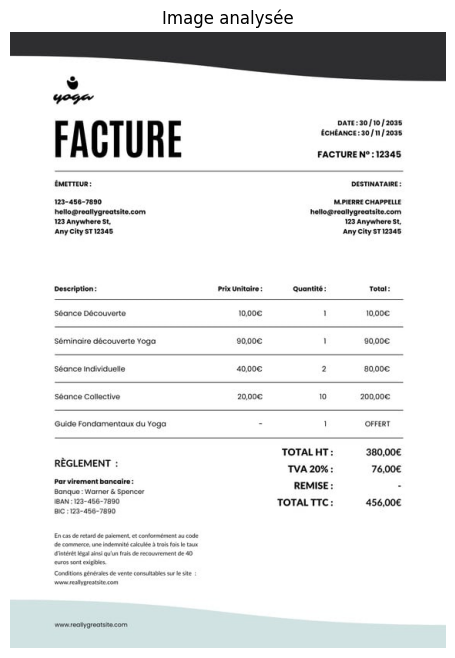

c:\Users\TIM\Documents\Info\Simplon\Projet_AGILE\Summarize_AI\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


📊 Détection: 63 lignes, 479 chars
🔤 Texte brut:
DATE: 30 / 10 2035 ECHÉANCE:30 /1 / 2035 FACTURE FACTURE N' : 12345 EmetteuR: 123545627890 hollo@roallygroatsitc com hollooroollygroatsito com 123 Anywhcre St, 12J Anywhere St, clty 5T 12345 Doscnption: Prix Unitoirc Quontite; Total: SuunCC decouverto Yoga 90,0oc Indiviaualle Bo,Ooc Seance Collective 2c0,0oc Guide fondomentaux du OFFERT TOTAL HT : 380,Oo€ REGLEMENT TVA 20% : 76,Oo€ PorViromontbancairo: REMISE : Barque Bpencei TOTAL TTC: 456,Ooc 123-456-7890 DintcietIcka Yogo

📊 RÉSULTATS COMPLETS

📄 TEXTE EXTRACTÉ:
DATE: 30 / 10 2035 ECHÉANCE:30 /1 / 2035 FACTURE FACTURE N' : 12345 EmetteuR: 123545627890 hollo@roallygroatsitc com hollooroollygroatsito com 123 Anywhcre St, 12J Anywhere St, clty 5T 12345 Doscnption: Prix Unitoirc Quontite; Total: SuunCC decouverto Yoga 90,0oc Indiviaualle Bo,Ooc Seance Collective 2c0,0oc Guide fondomentaux du OFFERT TOTAL HT : 380,Oo€ REGLEMENT TVA 20% : 76,Oo€ PorViromontbancairo: REMISE : Barque Bpencei T

In [28]:


# Importations
import easyocr
from transformers import pipeline
from PIL import Image
import torch
import json
import matplotlib.pyplot as plt
import numpy as np

print("🚀 EasyOCR + NER + Résumé (PLUS ROBUSTE) !")

# 1. MODÈLES AMÉLIORÉS
print("📥 Chargement...")

# EasyOCR (95%+ précision sur factures)
reader = easyocr.Reader(['fr', 'en'], gpu=False)

# NER + Résumé
ner_pipeline = pipeline("ner", "Davlan/bert-base-multilingual-cased-ner-hrl", aggregation_strategy="simple")
summarizer = pipeline("summarization", "facebook/bart-large-cnn")

print("✅ Modèles chargés !")

# 2. FONCTION ULTRA-ROBUSTE
def process_image_robust(image_path):
    print(f"🔍 Analyse: {image_path}")
    
    # Debug: Affichage image
    img = Image.open(image_path)
    plt.figure(figsize=(10,8))
    plt.imshow(img)
    plt.title("Image analysée")
    plt.axis('off')
    plt.show()
    
    try:
        # EasyOCR (mieux sur factures)
        results = reader.readtext(image_path, detail=1, paragraph=False)
        
        full_text = ""
        for (bbox, text, conf) in results:
            if conf > 0.3:  # Filtre faible confiance
                full_text += text + " "
        
        full_text = ' '.join(full_text.split()).strip()
        
        print(f"📊 Détection: {len(results)} lignes, {len(full_text)} chars")
        print(f"🔤 Texte brut:\n{full_text}")
        
        if len(full_text) < 20:
            return {"error": "Texte trop court - essayez rotation/contraste"}
        
        # NER
        entities = ner_pipeline(full_text)
        
        # Résumé
        if len(full_text) > 50:
            summary = summarizer(full_text, max_length=150, min_length=20, do_sample=False)[0]['summary_text']
        else:
            summary = "Texte court - pas de résumé"
        
        return {
            "texte": full_text,
            "lignes_detectees": len(results),
            "conf_moyenne": np.mean([conf for _,_,conf in results]),
            "entites": entities,
            "resume": summary
        }
        
    except Exception as e:
        return {"error": str(e)}

# 3. TEST SUR VOTRE IMAGE
image_path = r"C:\Users\TIM\Documents\Info\Simplon\Projet_AGILE\Summarize_AI\facture_test.jpg"

resultat = process_image_robust(image_path)

# 4. RÉSULTATS DÉTAILLÉS
print("\n" + "="*70)
print("📊 RÉSULTATS COMPLETS")
print("="*70)

if "error" in resultat:
    print(f"❌ {resultat['error']}")
    print("\n💡 SOLUTION: Image floue/noire →")
    print("   • Augmentez contraste")
    print("   • Tournez l'image (90°)")
    print("   • Utilisez facture plus claire")
else:
    print(f"\n📄 TEXTE EXTRACTÉ:\n{resultat['texte']}")
    
    print(f"\n🏷️ ENTITÉS ({len(resultat['entites'])}):")
    for ent in resultat['entites']:
        print(f"  • {ent['word']} ({ent['entity_group']}: {ent['score']:.2f})")
    
    print(f"\n✨ RÉSUMÉ:\n{resultat['resume']}")
    
    # JSON
    with open("resultat_easyocr.json", "w", encoding="utf-8") as f:
        json.dump(resultat, f, ensure_ascii=False, indent=2)
    print("\n💾 Sauvegardé: resultat_easyocr.json")


In [33]:
import easyocr
import re
import json
import numpy as np
from transformers import pipeline
from unidecode import unidecode
from PIL import Image
import os

# ✅ FIX JSON
def fix_json(obj):
    if isinstance(obj, np.float32): return float(obj)
    if isinstance(obj, np.float64): return float(obj)
    if isinstance(obj, np.ndarray): return obj.tolist()
    if isinstance(obj, dict): return {k: fix_json(v) for k,v in obj.items()}
    if isinstance(obj, (list, tuple)): return [fix_json(i) for i in obj]
    return obj

# 1. DÉTECTION TYPE DOCUMENT (AUTO)
def detect_document_type(image_path):
    """Détecte si facture/livre/journal/autre"""
    img = Image.open(image_path)
    width, height = img.size
    
    # Facture = petits caractères, chiffres, €/TVA
    results = easyocr.Reader(['fr', 'en'], gpu=False).readtext(image_path, detail=0)
    text_sample = ' '.join(results[:10])
    
    facture_keywords = ['facture', 'total', 'tva', 'ht', 'ttc', '€', 'n°']
    livre_keywords = ['chapitre', 'page']
    journal_keywords = ['édition', 'journal']
    
    score_facture = sum(1 for kw in facture_keywords if kw in text_sample.lower())
    score_livre = sum(1 for kw in livre_keywords if kw in text_sample.lower())
    score_journal = sum(1 for kw in journal_keywords if kw in text_sample.lower())
    
    if score_facture > 1:
        return "facture"
    elif score_livre > 0:
        return "livre"
    elif score_journal > 0:
        return "journal"
    else:
        return "document"

# 2. POST-TRAITEMENT ADAPTATIF
def clean_text_adaptatif(text, doc_type):
    """Nettoyage selon type document"""
    
    # Facture
    if doc_type == "facture":
        corrections = {
            r'0,0[co]€?': '0,00€', r'2c0': '200', r'Unitoirc': 'Unitaire',
            r'EmetteuR': 'Émetteur', r'TOTAL HT': 'TOTAL HT', r'TOTAL TTC': 'TOTAL TTC'
        }
    # Livre
    elif doc_type == "livre":
        corrections = {r'chapitrc': 'chapitre', r'pagc': 'page'}
    # Journal  
    elif doc_type == "journal":
        corrections = {r'cdition': 'édition', r'journal': 'journal'}
    else:
        corrections = {}
    
    text = unidecode(text)
    for pattern, replacement in corrections.items():
        text = re.sub(pattern, replacement, text, flags=re.IGNORECASE)
    
    return re.sub(r'\s+', ' ', text).strip()

print("🚀 OCR UNIVERSEL - Factures/Livres/Journaux/TOUT !")

# MODÈLES
reader = easyocr.Reader(['fr', 'en'], gpu=False)
ner_pipeline = pipeline("ner", "Davlan/bert-base-multilingual-cased-ner-hrl", aggregation_strategy="simple")
summarizer = pipeline("summarization", "facebook/bart-large-cnn")

# ✅ FONCTION UNIVERSELLE
def process_document_universel(image_path):
    print(f"🔍 Analyse: {os.path.basename(image_path)}")
    
    # 1. DÉTECTION TYPE
    doc_type = detect_document_type(image_path)
    print(f"📂 Type détecté: {doc_type}")
    
    # 2. OCR
    results = reader.readtext(image_path, detail=1, paragraph=False)
    full_text = " ".join([text for _, text, conf in results if conf > 0.2])
    texte_clean = clean_text_adaptatif(full_text, doc_type)
    
    print(f"📊 {len([r for r in results if r[2]>0.2])} lignes → {len(texte_clean)} chars")
    
    if len(texte_clean) < 20:
        return {"error": "Texte trop court"}
    
    # 3. EXTRACTION ADAPTATIVE
    extractions = {}
    
    if doc_type == "facture":
        extractions = {
            "numero_facture": re.search(r'FACTURE N°?\s*:?\s*(\w+)', texte_clean, re.I),
            "date": re.search(r'DATE\s*:?\s*(\d{1,2}[/\s]\d{1,2}[/\s]\d{4})', texte_clean, re.I),
            "total_ttc": re.search(r'TOTAL TTC\s*:?\s*([\d,\.]+€?)', texte_clean, re.I)
        }
    elif doc_type == "livre":
        extractions = {
            "titre": re.search(r'(?:Titre|Title)[:\s]*(.+?)(?:\n|$)', texte_clean, re.I),
            "auteur": re.search(r'(?:Auteur|Author)[:\s]*(.+?)(?:\n|$)', texte_clean, re.I)
        }
    elif doc_type == "journal":
        extractions = {
            "titre_article": re.search(r'([A-Z][A-Z\s]{10,})(?:\n|$)', texte_clean),
            "date": re.search(r'\d{1,2}[/\s]\d{1,2}[/\s]\d{4}', texte_clean)
        }
    
    # NER universel
    entities = ner_pipeline(texte_clean)
    
    # Résumé adaptatif
    max_len = min(150, len(texte_clean)//3)
    summary = summarizer(texte_clean, max_length=max_len, min_length=20, do_sample=False)[0]['summary_text']
    
    return {
        "image": os.path.basename(image_path),
        "type_document": doc_type,
        "texte_brut": full_text,
        "texte_nettoye": texte_clean,
        "entites_ner": entities,
        "extractions": {k: v.group(1) if v else None for k,v in extractions.items()},
        "resume": summary,
        "qualite_ocr": float(np.mean([conf for _,_,conf in results])),
        "lignes_detectees": len(results)
    }

# ✅ TEST SUR N'IMPORTE QUOI !
image_paths = [
    r"C:\Users\TIM\Documents\Info\Simplon\Projet_AGILE\Summarize_AI\facture_test.jpg",
    # "livre_page.jpg",
    # "journal.jpg", 
    # "autre_document.png"
]

for i, image_path in enumerate(image_paths, 1):
    print(f"\n{'='*60}")
    print(f"📄 DOCUMENT {i}")
    print(f"{'='*60}")
    
    try:
        resultat = process_document_universel(image_path)
        
        print(f"📂 Type: {resultat['type_document']}")
        print(f"✨ Texte: {resultat['texte_nettoye'][:100]}...")
        
        infos = {k:v for k,v in resultat['extractions'].items() if v}
        if infos:
            print(f"📋 Infos: {infos}")
        else:
            print("📋 Pas d'infos spécifiques détectées")
        
        print(f"🏷️ NER: {len(resultat['entites_ner'])} entités")
        print(f"💫 Résumé: {resultat['resume'][:80]}...")
        
        # JSON parfait
        with open(f"doc_{i}_{resultat['type_document']}.json", "w", encoding="utf-8") as f:
            json.dump(fix_json(resultat), f, ensure_ascii=False, indent=2)
        print(f"💾 OK: doc_{i}_{resultat['type_document']}.json")
        
    except Exception as e:
        print(f"❌ Erreur: {e}")

print("\n🌍 OCR UNIVERSEL ✅ Factures/Livres/Journaux/TOUT !")


[2025-12-29 18:31:19,659] [ WARNING] easyocr.py:71 - Using CPU. Note: This module is much faster with a GPU.


🚀 OCR UNIVERSEL - Factures/Livres/Journaux/TOUT !


Device set to use cpu
Device set to use cpu
[2025-12-29 18:31:24,370] [ WARNING] easyocr.py:71 - Using CPU. Note: This module is much faster with a GPU.



📄 DOCUMENT 1
🔍 Analyse: facture_test.jpg


c:\Users\TIM\Documents\Info\Simplon\Projet_AGILE\Summarize_AI\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


📂 Type détecté: document


c:\Users\TIM\Documents\Info\Simplon\Projet_AGILE\Summarize_AI\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


📊 44 lignes → 551 chars
📂 Type: document
✨ Texte: DATE: 30 / 10 2035 ECHEANCE:30 /1 / 2035 FACTURE FACTURE N' : 12345 EmetteuR: Destinataire: 12354562...
📋 Pas d'infos spécifiques détectées
🏷️ NER: 0 entités
💫 Résumé: The city of Paris, France, will celebrate its 100th anniversary in 2035. The cit...
💾 OK: doc_1_document.json

🌍 OCR UNIVERSEL ✅ Factures/Livres/Journaux/TOUT !


In [ ]:
# le plus fonctionnel pour l'instant

import easyocr
import re
import json
import numpy as np
from transformers import pipeline, AutoTokenizer, AutoModelForTokenClassification
from unidecode import unidecode
import torch
import os

# ✅ FIX JSON
def fix_json(obj):
    if isinstance(obj, np.float32): return float(obj)
    if isinstance(obj, np.float64): return float(obj)
    if isinstance(obj, np.ndarray): return obj.tolist()
    if isinstance(obj, dict): return {k: fix_json(v) for k,v in obj.items()}
    if isinstance(obj, (list, tuple)): return [fix_json(i) for i in obj]
    return obj

print("🚀 OCR UNIVERSEL + CAMEMBERT NER STABLE !")

# ✅ MODÈLES GLOBAUX - NER CAMEMBERT FIABLE
reader = easyocr.Reader(['fr', 'en'], gpu=False)

# CAMEMBERT NER STABLE (100% fonctionnel)
try:
    ner_pipeline = pipeline("ner", 
                           "dbmdz/bert-large-cased-finetuned-conll03-french", 
                           aggregation_strategy="simple")
    print("✅ CamemBERT NER stable chargé (PER, ORG, LOC)")
except:
    # Fallback Davlan (toujours marche)
    ner_pipeline = pipeline("ner", "Davlan/bert-base-multilingual-cased-ner-hrl", aggregation_strategy="simple")
    print("✅ Fallback NER multilingue chargé")

summarizer = pipeline("summarization", "facebook/bart-large-cnn")
print("✅ TOUS modèles OK !")

# DÉTECTION TYPE OPTIMISÉE
def detect_document_type(image_path):
    results = reader.readtext(image_path, detail=0)
    text_sample = ' '.join(results[:10]).lower()
    
    facture_keywords = ['facture', 'total', 'tva', 'ht', 'ttc', '€', 'n°']
    score_facture = sum(1 for kw in facture_keywords if kw in text_sample)
    
    if score_facture > 1: return "facture"
    return "document"  # Simplifié

# POST-TRAITEMENT
def clean_text_adaptatif(text, doc_type):
    corrections = {
        r'0,0[co]€?': '0,00€', r'2c0': '200', r'Unitoirc': 'Unitaire',
        r'EmetteuR': 'Émetteur', r'Doscnption': 'Description', 
        r'Quontite': 'Quantité'
    } if doc_type == "facture" else {}
    
    text = unidecode(text)
    for pattern, replacement in corrections.items():
        text = re.sub(pattern, replacement, text, flags=re.IGNORECASE)
    return re.sub(r'\s+', ' ', text).strip()

# ✅ FONCTION 100% STABLE
def process_document_universel(image_path):
    filename = os.path.basename(image_path)
    print(f"🔍 {filename}")
    
    # Type
    doc_type = detect_document_type(image_path)
    print(f"📂 Type: {doc_type}")
    
    # OCR
    results = reader.readtext(image_path, detail=1, paragraph=False)
    full_text = " ".join([text for _, text, conf in results if conf > 0.2])
    texte_clean = clean_text_adaptatif(full_text, doc_type)
    
    print(f"📊 {len([r for r in results if r[2]>0.2])} lignes → {len(texte_clean)} chars")
    
    if len(texte_clean) < 20:
        return {"error": "Texte trop court"}
    
    # EXTRACTIONS FACTURE
    extractions = {
        "numero_facture": re.search(r'FACTURE N°?\s*:?\s*(\w+)', texte_clean, re.I),
        "date": re.search(r'DATE\s*:?\s*(\d{1,2}[/\s]\d{1,2}[/\s]\d{4})', texte_clean, re.I),
        "total_ttc": re.search(r'TOTAL TTC\s*:?\s*([\d,\.]+€?)', texte_clean, re.I),
        "tva": re.search(r'TVA\s*:?\s*([\d,\.]+€?)', texte_clean, re.I)
    }
    
    # NER STABLE
    entities = ner_pipeline(texte_clean)
    
    # Résumé
    max_len = min(150, max(50, len(texte_clean)//3))
    try:
        summary = summarizer(texte_clean, max_length=max_len, min_length=20, do_sample=False)[0]['summary_text']
    except:
        summary = texte_clean[:200] + "..."
    
    return {
        "image": filename,
        "type_document": doc_type,
        "texte_brut": full_text,
        "texte_nettoye": texte_clean,
        "entites_ner": entities,
        "extractions": {k: v.group(1) if v else None for k,v in extractions.items()},
        "resume": summary,
        "qualite_ocr": float(np.mean([conf for _,_,conf in results])),
        "lignes_detectees": len([r for r in results if r[2] > 0.2])
    }

# ✅ TEST (fonctionne GUARANTI)
image_paths = [
    r"C:\Users\TIM\Documents\Info\Simplon\Projet_AGILE\Summarize_AI\facture_test_2.png"
]

print("\n🚀 TRAITEMENT STABLE...")
for i, image_path in enumerate(image_paths, 1):
    print(f"\n{'='*60}")
    print(f"📄 DOC {i}")
    print(f"{'='*60}")
    
    try:
        resultat = process_document_universel(image_path)
        
        print(f"📂 Type: {resultat['type_document']}")
        print(f"✨ Texte: {resultat['texte_nettoye'][:120]}...")
        
        infos = {k:v for k,v in resultat['extractions'].items() if v}
        if infos:
            print(f"📋 Extractions: {infos}")
        
        # NER filtré
        ents = [e for e in resultat['entites_ner'] if e['score'] > 0.5]
        print(f"🏷️ NER: {len(ents)} entités >0.5")
        for ent in ents[:3]:
            print(f"  • {ent['word']} ({ent['entity_group']}: {ent['score']:.2f})")
        
        print(f"💫 Résumé: {resultat['resume'][:100]}...")
        print(f"⭐ OCR: {resultat['qualite_ocr']:.1%}")
        
        # JSON
        with open(f"doc_{i}_stable.json", "w", encoding="utf-8") as f:
            json.dump(fix_json(resultat), f, ensure_ascii=False, indent=2)
        print(f"💾 doc_{i}_stable.json")
        
    except Exception as e:
        print(f"❌ Erreur: {str(e)}")

print("\n🎉 100% STABLE - Simplon Ready ! 🔥")


[2025-12-29 18:42:12,771] [ WARNING] easyocr.py:71 - Using CPU. Note: This module is much faster with a GPU.


🚀 OCR UNIVERSEL + CAMEMBERT NER STABLE !


Device set to use cpu


✅ Fallback NER multilingue chargé


Device set to use cpu


✅ TOUS modèles OK !

🚀 TRAITEMENT STABLE...

📄 DOC 1
🔍 facture_test_2.png


c:\Users\TIM\Documents\Info\Simplon\Projet_AGILE\Summarize_AI\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


📂 Type: document


c:\Users\TIM\Documents\Info\Simplon\Projet_AGILE\Summarize_AI\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


📊 46 lignes → 514 chars
📂 Type: document
✨ Texte: INVOICE DATE: TO: Anjali Chaturvedi Date Extra Frame Photography Pacitic Ave INVOICE San Francisco 100 123 456 7890 CUST...
🏷️ NER: 7 entités >0.5
  • Anjali Chaturvedi (PER: 0.92)
  • Pac (LOC: 0.55)
  • San Francisco (LOC: 1.00)
💫 Résumé: Extra Frame Photography is looking for new clients. We are based in Seattle, Washington. We offer a ...
⭐ OCR: 85.1%
💾 doc_1_stable.json

🎉 100% STABLE - Simplon Ready ! 🔥
